In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA


In [62]:
path = "../data/processed_data.csv"
df = pd.read_csv(path)
df = df.replace([np.inf, -np.inf], np.nan).dropna()
print(f"Shape: {df.shape}, NaNs: {df.isna().sum().sum()}")
df.head()


Shape: (1470, 37), NaNs: 0


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,PerformanceIndex,...,YearsWithCurrManager,RemoteWork,MonthlyIncome,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,StressRating
0,0.448696,2.275186,0.590048,1.401512,-1.013529,-0.888082,-0.938496,-0.660531,-1.231716,1.383138,...,0.245533,-1.484408,-0.859256,-1.326566,-1.216109,-0.645124,-0.581016,-1.107823,-1.162892,1.700002
1,1.323184,-0.439525,-0.913194,-0.493817,-0.152180,-1.863778,-0.938496,0.254625,0.811876,-0.240677,...,0.805990,0.142795,-0.029982,1.326566,0.822295,-0.645124,-0.581016,0.902671,-1.162892,-0.565640
2,0.011452,2.275186,0.590048,-0.493817,-0.890479,-0.888082,1.318192,1.169781,0.811876,1.284725,...,-1.155608,-0.670806,0.348985,-0.442189,0.822295,-0.645124,-0.581016,-1.107823,-1.162892,0.567181
3,-0.425792,-0.439525,-0.913194,-0.493817,-0.767430,1.063309,-0.938496,1.169781,-1.231716,-0.486709,...,-1.155608,-0.670806,2.187149,1.326566,0.822295,1.550090,1.721123,0.902671,-1.162892,-1.698461
4,-1.081659,-0.439525,0.590048,-0.493817,-0.890479,-1.863778,0.565963,-1.575686,0.811876,-1.274014,...,-0.595151,-0.670806,-1.969845,-0.442189,-1.216109,-0.645124,-0.581016,-1.107823,0.943641,0.567181


In [63]:

class LinearRegression:
    """
    Custom implementation of linear regression using gradient descent.
    """
    def __init__(self, learning_rate=0.0001, n_iterations=100000):
        self.coef_ = None
        self.intercept_ = None
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

    def fit(self, X, y):
        """
        Fits the linear regression model to the given data using gradient descent.
        Args:
            X: A numpy array of shape (n_samples, n_features) representing the input data.
            y: A numpy array of shape (n_samples,) representing the target values.
        """
        m, n = X.shape
        self.coef_ = np.zeros((n, 1)) if y.ndim == 2 else np.zeros(n)
        self.intercept_ = 0.0

        for _ in range(self.n_iterations):
            # Calculate the predictions
            y_pred = self.predict(X)

            # Compute the residuals (raw difference, NOT squared)
            residual = y_pred - y

            # Calculate gradients for MSE loss
            intercept_gradient = (2/m) * np.sum(residual)
            coef_gradient = (2/m) * np.dot(X.T, residual)

            # Clip gradients to prevent overflow
            intercept_gradient = np.clip(intercept_gradient, -1e6, 1e6)
            coef_gradient = np.clip(coef_gradient, -1e6, 1e6)

            # Update the parameters using the gradients
            self.intercept_ -= self.learning_rate * intercept_gradient
            self.coef_ -= self.learning_rate * coef_gradient

            # Early stop if weights diverge
            if np.any(np.isnan(self.coef_)) or np.isnan(self.intercept_):
                print("Warning: NaN detected, stopping early. Try a smaller learning_rate.")
                break

    def predict(self, X):
        """
        Predicts the target values for new data.
        Args:
            X: A numpy array of shape (n_samples, n_features) representing the new input data.
        Returns:
            A numpy array of shape (n_samples,) representing the predicted target values.
        """
        return np.dot(X, self.coef_) + self.intercept_


In [64]:

class WeightedEnsemble:
    """
    Custom R²-weighted ensemble model (built from scratch).
    
    Combines multiple sub-model predictions using their R² scores as weights.
    Better-performing models get more influence on the final prediction.
    Models with negative R² (worse than predicting the mean) are excluded.
    
    Formula:
        ŷ_ensemble = Σ( max(R²_i, 0) * ŷ_i ) / Σ( max(R²_i, 0) )
    
    Works for both regression (R²-weighted) and classification (accuracy-weighted).
    """
    
    def __init__(self):
        self.sub_models = {}   # name -> {score, predictions}
        self.weights = {}      # name -> normalized weight
    
    def add(self, name, score, predictions):
        """
        Register a sub-model's performance score and predictions.
        
        Args:
            name: Identifier for the sub-model.
            score: Performance metric (R² for regression, accuracy for classification).
                   Used as the weight — higher = more influence.
            predictions: The model's predictions on the test set (numpy array).
        """
        self.sub_models[name] = {
            'score': score,
            'predictions': predictions.flatten() if predictions.ndim > 1 else predictions
        }
    
    def _compute_weights(self):
        """Compute normalized weights from scores (negative scores clipped to 0)."""
        # Clip negative scores to 0 (they're worse than baseline)
        raw_weights = {name: max(info['score'], 0) 
                       for name, info in self.sub_models.items()}
        total = sum(raw_weights.values())
        
        if total == 0:
            # Fallback: equal weights if all models are terrible
            n = len(raw_weights)
            self.weights = {name: 1.0 / n for name in raw_weights}
        else:
            self.weights = {name: w / total for name, w in raw_weights.items()}
        
        return self.weights
    
    def predict(self):
        """
        Compute the weighted ensemble prediction.
        
        Returns:
            numpy array of ensemble predictions.
        """
        self._compute_weights()
        
        y_ensemble = None
        for name, info in self.sub_models.items():
            w = self.weights[name]
            contribution = w * info['predictions']
            if y_ensemble is None:
                y_ensemble = contribution.copy()
            else:
                y_ensemble += contribution
        
        return y_ensemble
    
    def get_weight_summary(self):
        """Print the weight distribution across sub-models."""
        self._compute_weights()
        print("Ensemble Weight Distribution:")
        print("-" * 50)
        for name, w in sorted(self.weights.items(), key=lambda x: -x[1]):
            r2 = self.sub_models[name]['score']
            bar = "█" * int(w * 30)
            print(f"  {name:25s} | R²={r2:.4f} | w={w:.4f} {bar}")
        print("-" * 50)


In [65]:
target = 'StressRating'

# Find the best single feature by correlation
corrs = df.corr(numeric_only=True)[target].drop(target).abs().sort_values(ascending=False)
best_feature = corrs.index[0]
print(f"Best feature: {best_feature} (|corr| = {corrs.iloc[0]:.4f})")
print(f"Top 5:\n{corrs.head(5)}")

X = df.drop(columns=[target])
y = df[target].values.reshape(-1, 1)
print(f"\nX shape: {X.shape}, y shape: {y.shape}")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Best feature: WelfareBenefits (|corr| = 0.5882)
Top 5:
WelfareBenefits       0.588156
ExternalFacility      0.559452
InHouseFacility       0.552787
StressSelfReported    0.504541
FlexibleWork          0.453103
Name: StressRating, dtype: float64

X shape: (1470, 36), y shape: (1470, 1)


=== Simple LR: WelfareBenefits -> StressRating ===

MSE: 0.7168 | RMSE: 0.8466 | R²: 0.3300


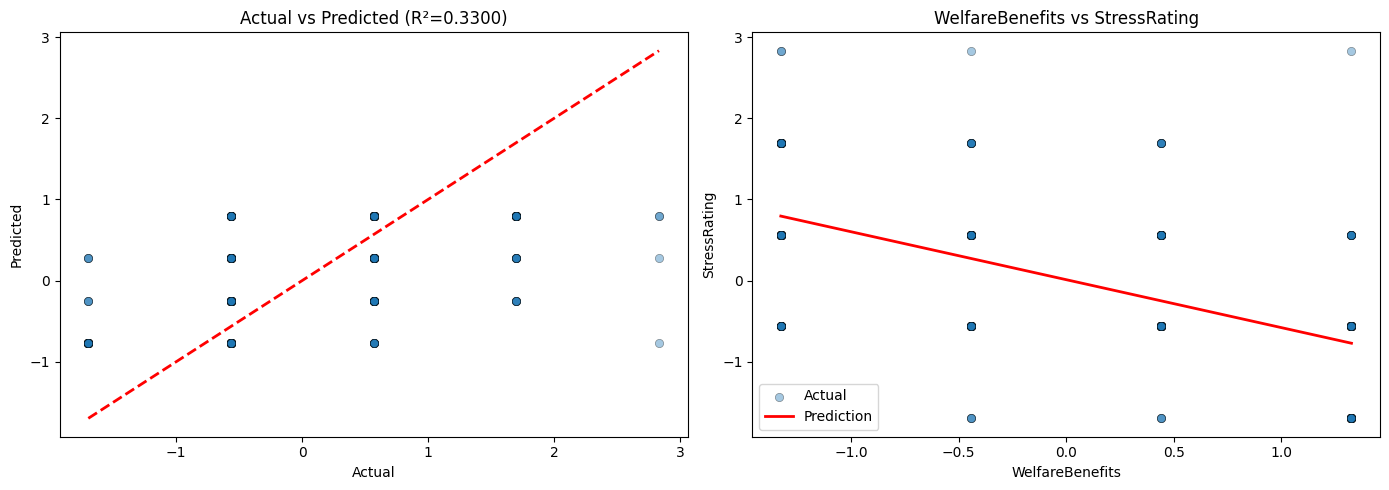

In [66]:
# === 1. Simple Linear Regression (Best Single Feature) ===
print(f"=== Simple LR: {best_feature} -> {target} ===\n")

X_train_simple = X_train[[best_feature]].values
X_test_simple = X_test[[best_feature]].values

model_simple = LinearRegression(learning_rate=0.001, n_iterations=100000)
model_simple.fit(X_train_simple, y_train)
y_pred_simple = model_simple.predict(X_test_simple)

mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test, y_pred_simple)
print(f"MSE: {mse_simple:.4f} | RMSE: {rmse_simple:.4f} | R²: {r2_simple:.4f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_simple, alpha=0.4, edgecolors='k', linewidths=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set(xlabel="Actual", ylabel="Predicted", title=f"Actual vs Predicted (R²={r2_simple:.4f})")

idx = X_test_simple.flatten().argsort()
axes[1].scatter(X_test_simple.flatten(), y_test.flatten(), alpha=0.4, label='Actual', edgecolors='k', linewidths=0.5)
axes[1].plot(X_test_simple.flatten()[idx], y_pred_simple.flatten()[idx], 'r-', lw=2, label='Prediction')
axes[1].set(xlabel=best_feature, ylabel=target, title=f"{best_feature} vs {target}")
axes[1].legend()

plt.tight_layout()
plt.show()

=== Multiple Regression with PCA -> StressRating ===

PCA 80%: 19 components (explains 0.8009)
MSE: 0.4735 | RMSE: 0.6881 | R²: 0.5574

PCA 95%: 29 components (explains 0.9564)
MSE: 0.4548 | RMSE: 0.6744 | R²: 0.5749



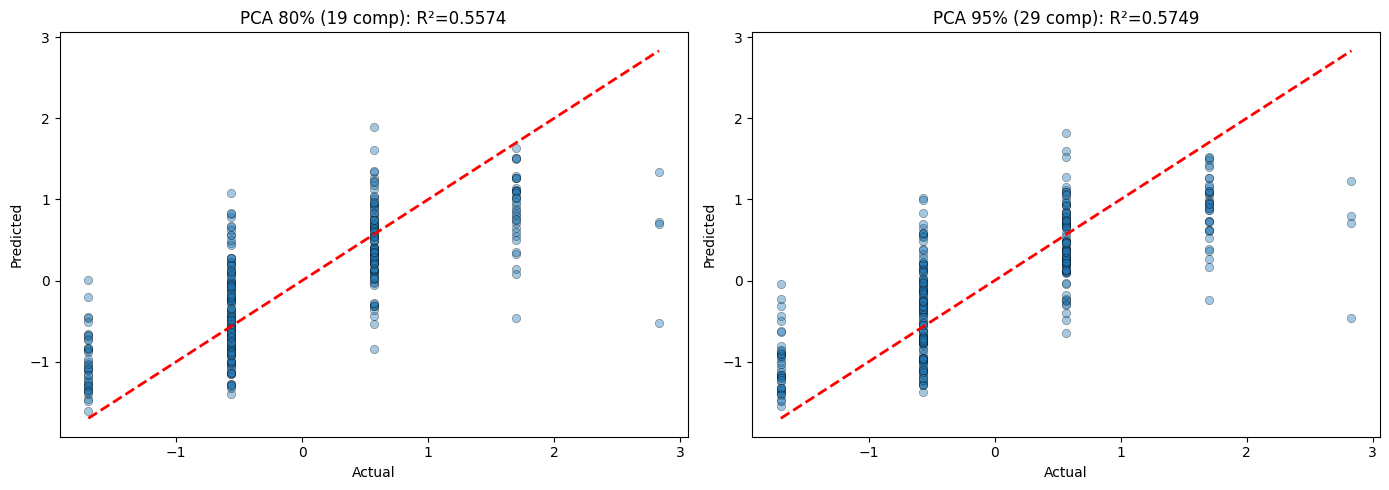

In [67]:
# === 2. Multiple Regression with PCA (80% and 95% variance) ===
print(f"=== Multiple Regression with PCA -> {target} ===\n")

results_pca = {}
for var_ratio in [0.80, 0.95]:
    pca = PCA(n_components=var_ratio)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    n_comp = pca.n_components_
    print(f"PCA {int(var_ratio*100)}%: {n_comp} components (explains {pca.explained_variance_ratio_.sum():.4f})")
    
    model_pca = LinearRegression(learning_rate=0.001, n_iterations=100000)
    model_pca.fit(X_train_pca, y_train)
    y_pred_pca = model_pca.predict(X_test_pca)
    
    mse_pca = mean_squared_error(y_test, y_pred_pca)
    r2_pca = r2_score(y_test, y_pred_pca)
    print(f"MSE: {mse_pca:.4f} | RMSE: {np.sqrt(mse_pca):.4f} | R²: {r2_pca:.4f}\n")
    
    results_pca[f"PCA {int(var_ratio*100)}%"] = {
        'n_components': n_comp, 'mse': mse_pca,
        'rmse': np.sqrt(mse_pca), 'r2': r2_pca, 'y_pred': y_pred_pca
    }

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, res) in zip(axes, results_pca.items()):
    ax.scatter(y_test, res['y_pred'], alpha=0.4, edgecolors='k', linewidths=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set(xlabel="Actual", ylabel="Predicted",
           title=f"{label} ({res['n_components']} comp): R²={res['r2']:.4f}")
plt.tight_layout()
plt.show()

=== Polynomial Regression: ['WelfareBenefits', 'ExternalFacility', 'InHouseFacility', 'StressSelfReported', 'FlexibleWork', 'ExtendedLeave', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'Attrition', 'DistanceFromHome', 'JobSatisfaction', 'JobInvolvement', 'RelationshipSatisfaction', 'OverTime', 'MonthlyIncome'] -> StressRating ===

Degree 2: 135 poly features
MSE: 0.4486 | RMSE: 0.6698 | R²: 0.5807



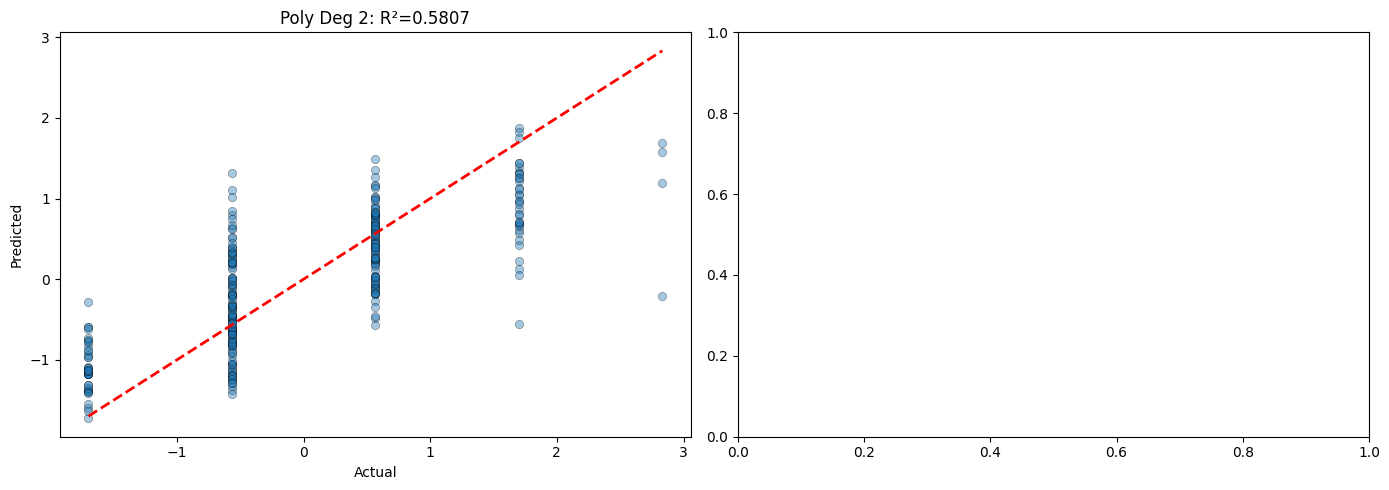

In [68]:
# === 3. Polynomial Regression (Degree 2 & 3, Top 3 Features) ===
top_features = corrs.head(15).index.tolist()
print(f"=== Polynomial Regression: {top_features} -> {target} ===\n")

X_train_poly_base = X_train[top_features].values
X_test_poly_base = X_test[top_features].values

results_poly = {}
for degree in [2]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_poly_base)
    X_test_poly = poly.transform(X_test_poly_base)
    
    model_poly = LinearRegression(learning_rate=0.001, n_iterations=100000)
    model_poly.fit(X_train_poly, y_train)
    y_pred_poly = model_poly.predict(X_test_poly)
    
    mse_poly = mean_squared_error(y_test, y_pred_poly)
    r2_poly = r2_score(y_test, y_pred_poly)
    print(f"Degree {degree}: {X_train_poly.shape[1]} poly features")
    print(f"MSE: {mse_poly:.4f} | RMSE: {np.sqrt(mse_poly):.4f} | R²: {r2_poly:.4f}\n")
    
    results_poly[f"Poly Deg {degree}"] = {
        'mse': mse_poly, 'rmse': np.sqrt(mse_poly), 'r2': r2_poly,
        'y_pred': y_pred_poly
    }

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, res) in zip(axes, results_poly.items()):
    ax.scatter(y_test, res['y_pred'], alpha=0.4, edgecolors='k', linewidths=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set(xlabel="Actual", ylabel="Predicted", title=f"{label}: R²={res['r2']:.4f}")
plt.tight_layout()
plt.show()

=== R²-Weighted Ensemble -> StressRating ===

Ensemble Weight Distribution:
--------------------------------------------------
  Poly Deg 2                | R²=0.5807 | w=0.2842 ████████
  PCA 95%                   | R²=0.5749 | w=0.2814 ████████
  PCA 80%                   | R²=0.5574 | w=0.2728 ████████
  Simple LR                 | R²=0.3300 | w=0.1615 ████
--------------------------------------------------

Ensemble MSE: 0.4458 | RMSE: 0.6677 | R²: 0.5833
Best individual R²: 0.5807
Ensemble improvement: +0.0026


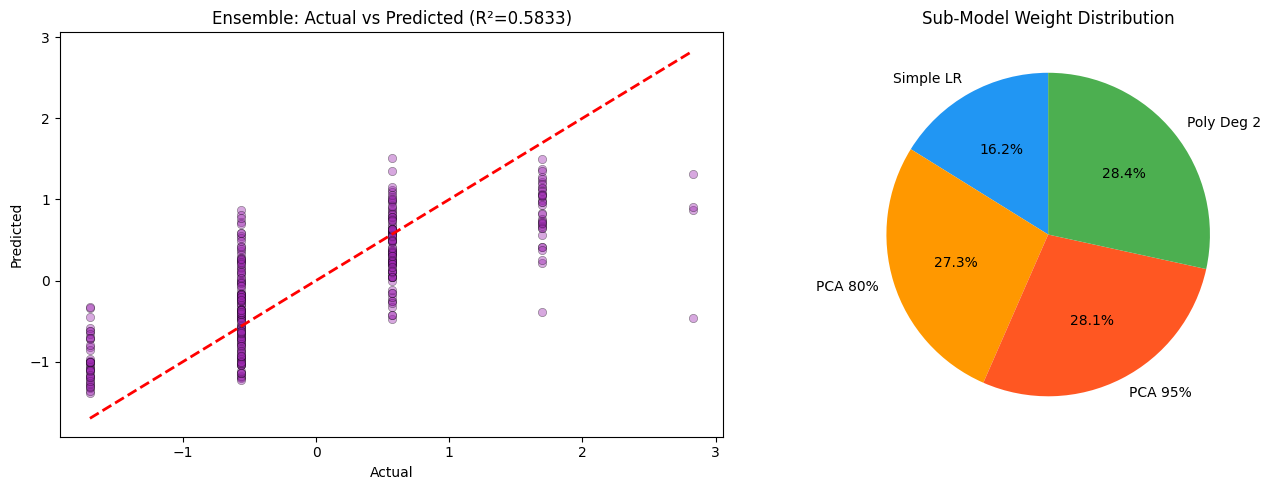

In [69]:

# === 4. R²-Weighted Ensemble (Custom Model) ===
# Combine all sub-model predictions, weighted by their R² performance
print(f"=== R²-Weighted Ensemble -> {target} ===\n")

ensemble = WeightedEnsemble()

# Add all sub-models with their R² scores and test predictions
ensemble.add("Simple LR", r2_simple, y_pred_simple)

for label, res in results_pca.items():
    ensemble.add(label, res['r2'], res['y_pred'])

for label, res in results_poly.items():
    ensemble.add(label, res['r2'], res['y_pred'])

# Show weight distribution
ensemble.get_weight_summary()

# Get ensemble prediction
y_pred_ensemble = ensemble.predict()

# Evaluate
mse_ensemble = mean_squared_error(y_test.flatten(), y_pred_ensemble)
rmse_ensemble = np.sqrt(mse_ensemble)
r2_ensemble = r2_score(y_test.flatten(), y_pred_ensemble)

print(f"\nEnsemble MSE: {mse_ensemble:.4f} | RMSE: {rmse_ensemble:.4f} | R²: {r2_ensemble:.4f}")

# Compare with best individual model
best_individual_r2 = max(r2_simple, 
                         max(res['r2'] for res in results_pca.values()),
                         max(res['r2'] for res in results_poly.values()))
improvement = r2_ensemble - best_individual_r2
print(f"Best individual R²: {best_individual_r2:.4f}")
print(f"Ensemble improvement: {improvement:+.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test.flatten(), y_pred_ensemble, alpha=0.4, edgecolors='k', linewidths=0.5, color='#9C27B0')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set(xlabel="Actual", ylabel="Predicted", title=f"Ensemble: Actual vs Predicted (R²={r2_ensemble:.4f})")

# Weight pie chart
weights = ensemble._compute_weights()
labels = list(weights.keys())
sizes = list(weights.values())
colors_pie = ['#2196F3', '#FF9800', '#FF5722', '#4CAF50', '#9C27B0']
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors_pie[:len(labels)], startangle=90)
axes[1].set_title("Sub-Model Weight Distribution")

plt.tight_layout()
plt.show()


=== Model Comparison ===

                      Model Features      MSE     RMSE       R²
Simple LR (WelfareBenefits)        1 0.716759 0.846616 0.329999
                    PCA 80%       19 0.473468 0.688090 0.557419
                    PCA 95%       29 0.454793 0.674383 0.574876
                 Poly Deg 2       15 0.448566 0.669750 0.580697
       R²-Weighted Ensemble      All 0.445798 0.667681 0.583284

Best model: R²-Weighted Ensemble (R² = 0.5833)


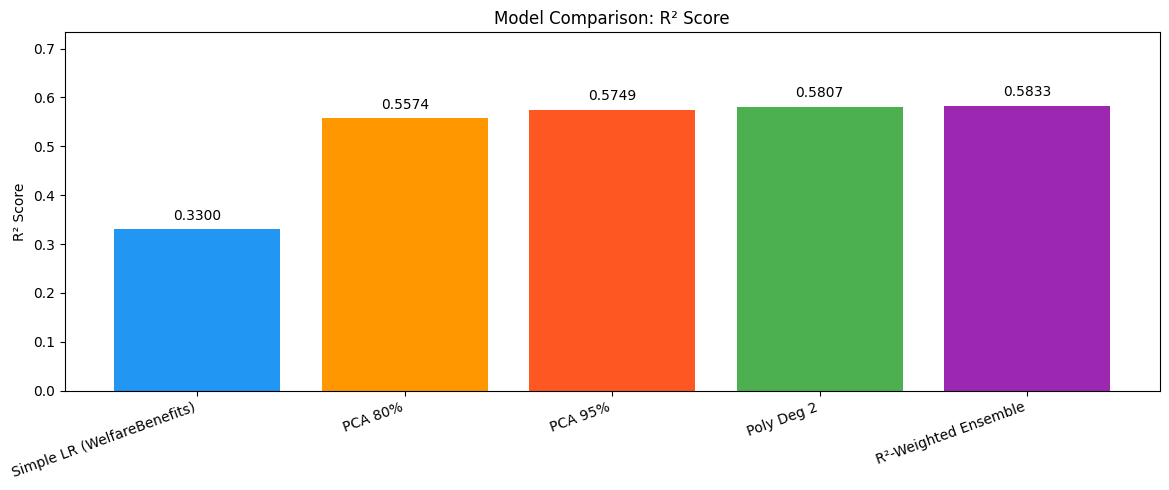

In [70]:
# === 5. Summary Comparison ===
summary_data = [
    {'Model': f'Simple LR ({best_feature})', 'Features': 1,
     'MSE': mse_simple, 'RMSE': rmse_simple, 'R²': r2_simple}
]
for label, res in results_pca.items():
    summary_data.append({'Model': label, 'Features': res['n_components'],
                         'MSE': res['mse'], 'RMSE': res['rmse'], 'R²': res['r2']})
for label, res in results_poly.items():
    summary_data.append({'Model': label, 'Features': len(top_features),
                         'MSE': res['mse'], 'RMSE': res['rmse'], 'R²': res['r2']})
# Add ensemble
summary_data.append({'Model': 'R²-Weighted Ensemble', 'Features': 'All',
                     'MSE': mse_ensemble, 'RMSE': rmse_ensemble, 'R²': r2_ensemble})

summary_df = pd.DataFrame(summary_data)
print("=== Model Comparison ===\n")
print(summary_df.to_string(index=False))

# Highlight best model
best_idx = summary_df['R²'].idxmax()
print(f"\nBest model: {summary_df.loc[best_idx, 'Model']} (R² = {summary_df.loc[best_idx, 'R²']:.4f})")

# R² bar chart
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2196F3', '#FF9800', '#FF5722', '#4CAF50', '#9C27B0']
bars = ax.bar(summary_df['Model'], summary_df['R²'], color=colors[:len(summary_df)])
ax.set_ylabel('R² Score')
ax.set_title('Model Comparison: R² Score')
ax.set_ylim(0, min(1.0, summary_df['R²'].max() + 0.15))
for bar, val in zip(bars, summary_df['R²']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', fontsize=10)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()